<a href="https://colab.research.google.com/github/CassandreDGN/PROJET_GPI_CD/blob/master/projetV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet de GPI**:

##First step : binning the image to run the code faster

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

%pip install Bio

import urllib.request
#import io
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile

import mrcfile

%pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=c641ff09-3d98-47b6-a6de-965b4c153bef
To: /content/map.mrc
100%|██████████| 228M/228M [00:01<00:00, 132MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: singlegrowing upbrain map 2D image


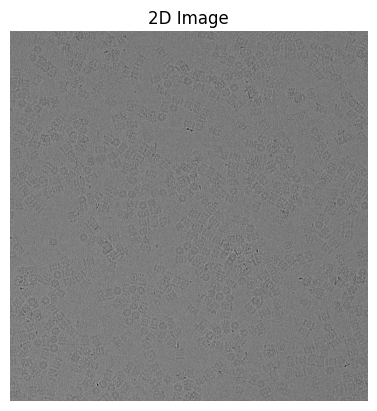

In [40]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: singlegrowing upbrain map 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

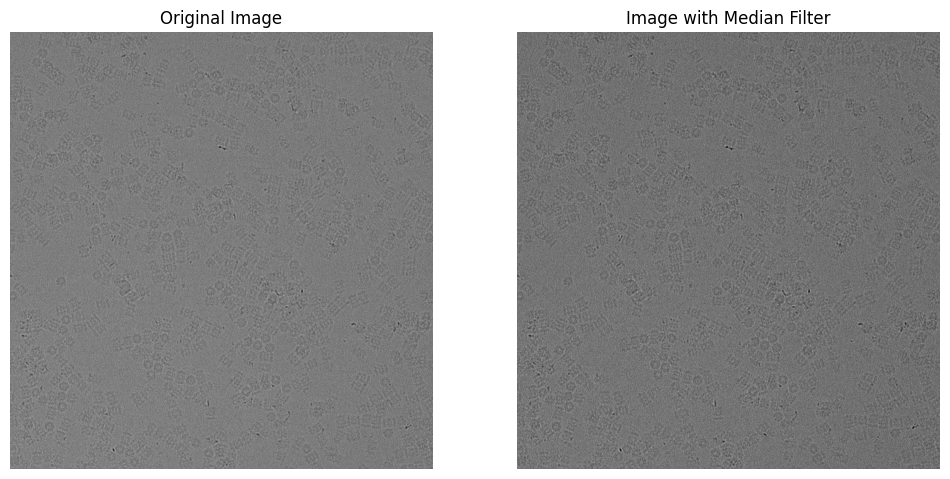

In [41]:
#add filter on picture to denoise before doing anything else

# Apply median filter
median_filtered_image = ndimage.median_filter(data, size=3)
median_filtered_image = np.clip(median_filtered_image, 0, 255).astype(np.uint8)

# Display the original and filtered images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(data, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(median_filtered_image, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
ax[1].set_title('Image with Median Filter')
ax[1].axis('off')

plt.show()

In [42]:
def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

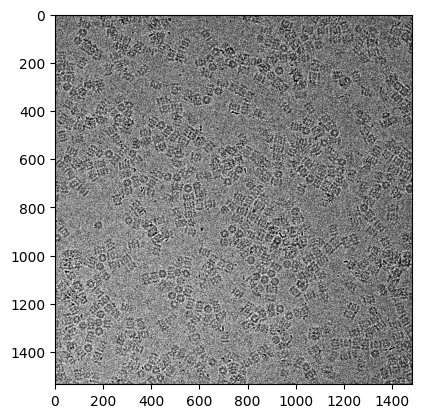

In [43]:
file_binned = bin_image(median_filtered_image,5)

plt.imshow(file_binned,cmap='gray', vmin=np.percentile(file_binned, 5), vmax=np.percentile(file_binned, 95))

array([[ 0.00428057,  0.00428057, -0.19486332, ..., -0.19486332,
        -0.19486332,  0.00428057],
       [ 0.00428057,  0.00428057,  0.00428057, ...,  0.00428057,
         0.20342446, -0.3940072 ],
       [ 0.20342446,  0.20342446,  0.20342446, ..., -0.19486332,
        -0.19486332, -0.19486332],
       ...,
       [-0.19486332,  0.00428057,  0.20342446, ..., -0.3940072 ,
        -0.19486332, -0.19486332],
       [ 0.20342446, -0.19486332,  0.00428057, ..., -0.19486332,
         0.00428057,  0.20342446],
       [ 0.00428057,  0.00428057,  0.40256834, ..., -0.19486332,
         0.20342446,  0.00428057]])

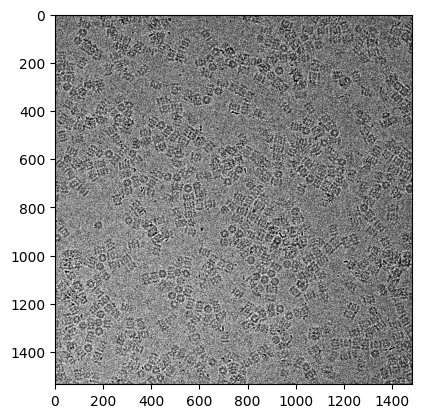

In [44]:
from mrcfile.dtypes import normalise_byte_order
#normalize image : substract average and divide by max


normalized_data = file_binned - np.mean(file_binned)
normalized_data /= np.max(normalized_data)



vmin2 = np.percentile(normalized_data, 5)
vmax2 = np.percentile(normalized_data, 95)  #have to change vmax value to use the new ones

plt.imshow(normalized_data,cmap='gray',vmin=vmin2, vmax=vmax2)

normalized_data

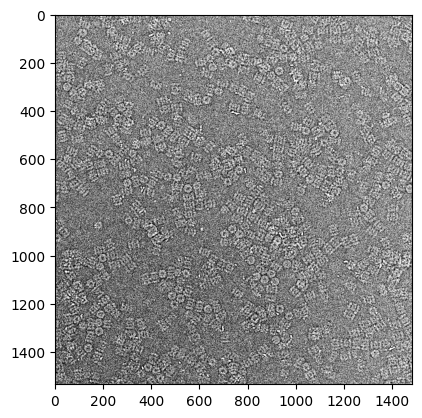

In [45]:
# inverting picture

binned_normalized_inverted_img = normalized_data*(-1)
plt.imshow(binned_normalized_inverted_img,cmap='gray', vmin=np.percentile(binned_normalized_inverted_img, 5), vmax=np.percentile(binned_normalized_inverted_img, 95))


In [46]:
# Padding(ton?)
# Function to apply different padding modes
def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:rana
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded


to exctrat coordinates we need to figure out a threshold

In [47]:
#padded_image = apply_padding(normalized_data, 400, mode= 'constant', constant_value=255)

padded_image = apply_padding(binned_normalized_inverted_img, 400, mode= 'edge')

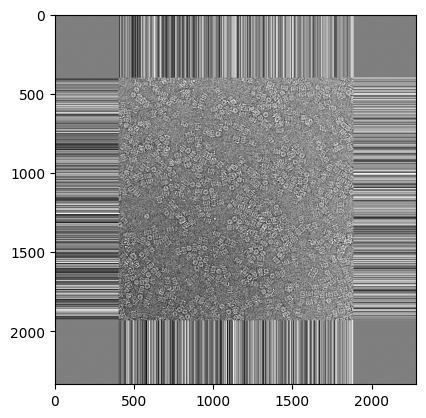

In [48]:
plt.imshow(padded_image,cmap='gray',vmin=np.percentile(padded_image, 5),vmax=np.percentile(padded_image, 95))

### still have to denoise and crop to make test image but anyway moving on

## Projection

✓ Successfully downloaded 3885327 bytes
✓ Saved to 6BDF.pdb

🧬 ATOMIC COORDINATES FROM 6BDF
Total atoms: 46382

First 10 atoms:
Atom   Residue  Res#  X (Å)      Y (Å)      Z (Å)      B-factor  
------------------------------------------------------------
N      THR         13    134.654    145.899     83.263      11.22
CA     THR         13    133.334    146.208     82.731       9.96
C      THR         13    133.169    147.713     82.532       9.51
O      THR         13    133.195    148.484     83.489      10.90
CB     THR         13    132.227    145.675     83.664      10.33
OG1    THR         13    132.360    144.258     83.812       9.81
CG2    THR         13    130.871    145.980     83.090      10.11
N      VAL         14    133.013    148.125     81.280      10.99
CA     VAL         14    132.845    149.535     80.936       8.68
C      VAL         14    131.640    149.722     80.041       8.78

Coordinate statistics:
  X range: [87.952, 207.696] Å
  Y range: [86.677, 207.946] Å

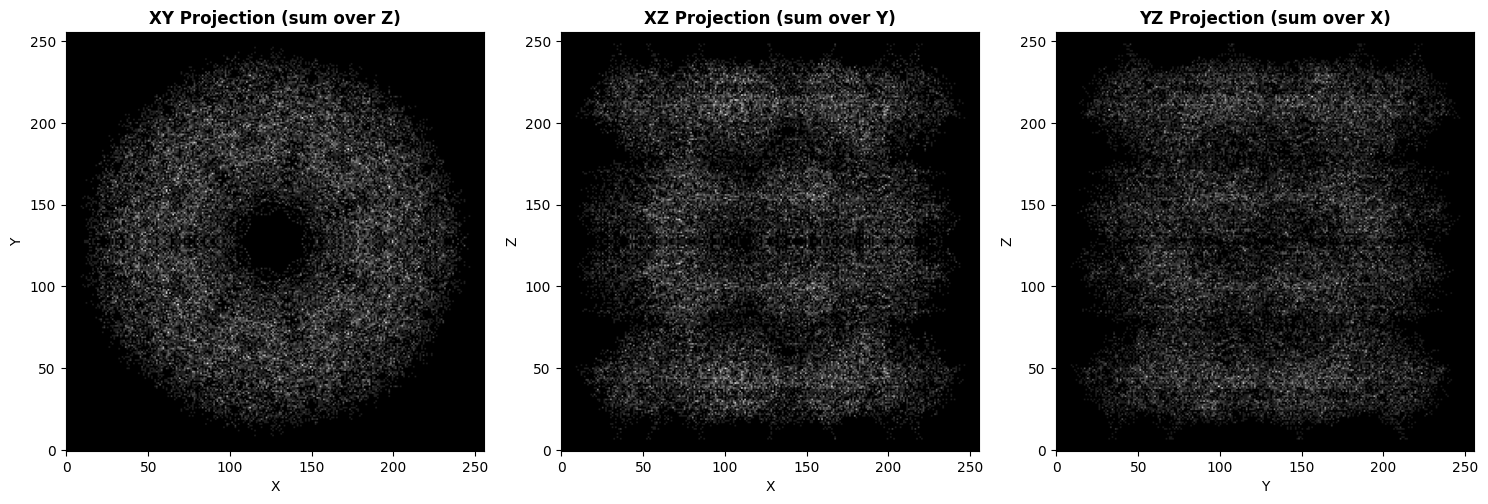


Summed Density Projections:
  - Pixel intensity = number of atoms projected into that pixel
  - Brighter = higher density
  - Approximates ideal projection images (no noise, no CTF)


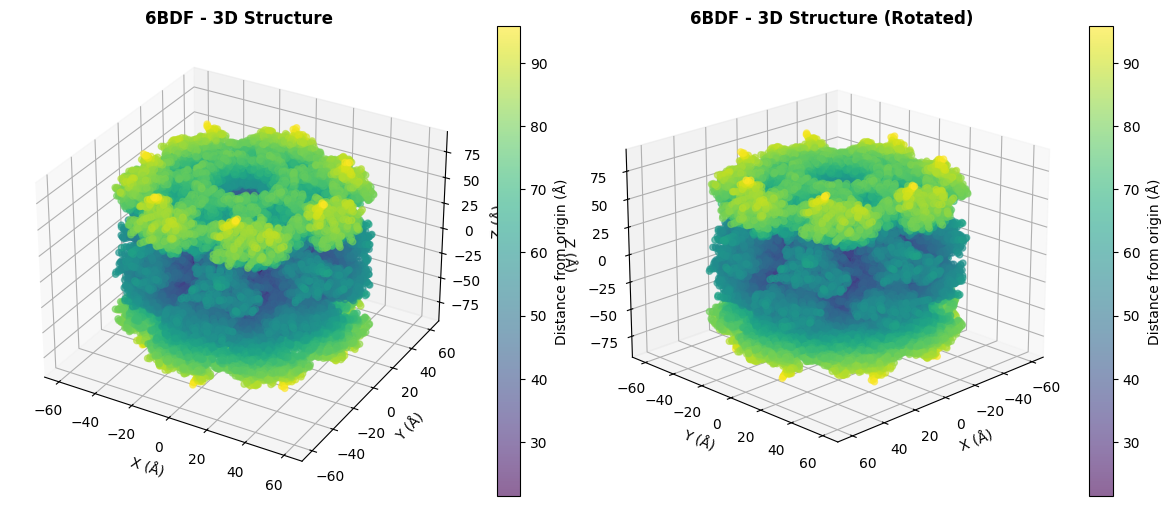

In [49]:

pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"✓ Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"✓ Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)



    # Extract t 7: Manipulating a PDt 7: Manipulating a PD coordinates
    print("\n" + "="*70)
    print("🧬 ATOMIC COORDINATES FROM 6BDF")
    print("="*70)

    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'name': atom.name,
                    'residue': residue.resname,
                    'residue_id': residue.id[1],
                    'x': coord[0],
                    'y': coord[1],
                    'z': coord[2],
                    'b_factor': atom.bfactor
                })

    print(f"Total atoms: {len(all_atoms)}")
    print(f"\nFirst 10 atoms:")
    print(f"{'Atom':6} {'Residue':8} {'Res#':5} {'X (Å)':10} {'Y (Å)':10} {'Z (Å)':10} {'B-factor':10}")
    print("-" * 60)
    for atom in all_atoms[:10]:
        print(f"{atom['name']:6} {atom['residue']:8} {atom['residue_id']:5d} {atom['x']:10.3f} {atom['y']:10.3f} {atom['z']:10.3f} {atom['b_factor']:10.2f}")

    # Extract coordinates for visualization
    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])

    print(f"\nCoordinate statistics:")
    print(f"  X range: [{coords[:, 0].min():.3f}, {coords[:, 0].max():.3f}] Å")
    print(f"  Y range: [{coords[:, 1].min():.3f}, {coords[:, 1].max():.3f}] Å")
    print(f"  Z range: [{coords[:, 2].min():.3f}, {coords[:, 2].max():.3f}] Å")

    print("\n" + "="*70)
    print("🎯 CREATING DENSITY-BASED 2D PROJECTIONS (SUMMED GRAYSCALE)")
    print("="*70)

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)

    # Resolution of projection image
    img_size = 256  # pixels
    padding = 5     # Å padding around structure

    # Function to create summed projection
    def create_projection(coord1, coord2, bins=256):
        # Determine bounds
        min1, max1 = coord1.min() - padding, coord1.max() + padding
        min2, max2 = coord2.min() - padding, coord2.max() + padding

        # 2D histogram (counts = density)
        H, xedges, yedges = np.histogram2d(coord1, coord2, bins=bins,
                                        range=[[min1, max1], [min2, max2]])

        # Normalize for display
        H = H / H.max()

        return H

    # Create projections
    proj_xy = create_projection(coords_centered[:, 0], coords_centered[:, 1], img_size)
    proj_xz = create_projection(coords_centered[:, 0], coords_centered[:, 2], img_size)
    proj_yz = create_projection(coords_centered[:, 1], coords_centered[:, 2], img_size)

    # Plot projections
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY projection
    axes[0].imshow(proj_xy.T, cmap='gray', origin='lower')
    axes[0].set_title('XY Projection (sum over Z)', fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # XZ projection
    axes[1].imshow(proj_xz.T, cmap='gray', origin='lower')
    axes[1].set_title('XZ Projection (sum over Y)', fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    # YZ projection
    axes[2].imshow(proj_yz.T, cmap='gray', origin='lower')
    axes[2].set_title('YZ Projection (sum over X)', fontweight='bold')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')

    plt.tight_layout()
    plt.show()

    print("\nSummed Density Projections:")
    print("  - Pixel intensity = number of atoms projected into that pixel")
    print("  - Brighter = higher density")
    print("  - Approximates ideal projection images (no noise, no CTF)")

    # 3D visualization
    fig = plt.figure(figsize=(12, 5))

    # 3D scatter plot
    ax4 = fig.add_subplot(1, 2, 1, projection='3d')
    scatter = ax4.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                          c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax4.set_xlabel('X (Å)', fontsize=10)
    ax4.set_ylabel('Y (Å)', fontsize=10)
    ax4.set_zlabel('Z (Å)', fontsize=10)
    ax4.set_title(f'{pdb_id} - 3D Structure', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax4, label='Distance from origin (Å)')

    # 3D scatter plot - rotated view
    ax5 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter2 = ax5.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                           c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax5.view_init(elev=20, azim=45)  # Different viewing angle
    ax5.set_xlabel('X (Å)', fontsize=10)
    ax5.set_ylabel('Y (Å)', fontsize=10)
    ax5.set_zlabel('Z (Å)', fontsize=10)
    ax5.set_title(f'{pdb_id} - 3D Structure (Rotated)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, ax=ax5, label='Distance from origin (Å)')

    plt.tight_layout()
    plt.show()


except urllib.error.URLError as e:
    print(f"❌ Error downloading PDB file: {e}")
    print("   Make sure you have internet connection")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {e}")